# Notebook 03: Cohort Comparison

Statistical comparison of trial outcomes between cohorts A and B.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os

sys.path.insert(0, os.path.join(os.getcwd(), '..'))
from src.data_loader import load_data
from src.cohort_analysis import (
    compute_cohort_stats, compare_cohorts_ttest,
    compare_adverse_event_rates, compare_compliance_trends,
    run_full_cohort_analysis
)

df = load_data('../data/clinical_trial_data.csv')
print(f'Loaded {len(df)} records')


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  File "/opt/anaconda3/lib/python3.12/site-

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/opt/anaconda3/lib/python3.12/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/opt/anaconda3/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 701, in start
    self.io_loop.start()
  File "/opt/anaconda3/lib/python3.12/site-

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



Loaded 6000 records


## 1. Cohort Descriptive Statistics

In [2]:
stats = compute_cohort_stats(df)
print(stats.to_string())

        num_patients  num_records  mean_outcome  std_outcome  median_outcome  mean_compliance  adverse_event_rate  mean_dosage  ci_95_lower  ci_95_upper
cohort                                                                                                                                                  
A                104         3120        87.643        8.328          88.490           87.909               0.112       75.296       87.351       87.935
B                 96         2880        82.990        8.287          83.455           88.561               0.110       75.200       82.687       83.293


## 2. Outcome Score Comparison (T-Test)

metric: outcome_score
cohort_a: A
cohort_b: B
mean_a: 87.643
mean_b: 82.99
std_a: 8.328
std_b: 8.287
n_a: 3120
n_b: 2880
t_statistic: 21.6791
p_value: 0.0
cohens_d: 0.5601
significant_at_05: True
significant_at_01: True
interpretation: There is a highly significant difference (p < 0.01) between cohorts A and B. The effect size is medium (Cohen's d = 0.560). Cohort A shows higher mean scores.


/var/folders/t_/7frv_55d3zgfg3vb628sx7m80000gn/T/ipykernel_75715/1201831431.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='cohort', y='outcome_score', ax=axes[0], palette='Set2')
/opt/anaconda3/lib/python3.12/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.12/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.12/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda3/lib/python3.12/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/anaconda

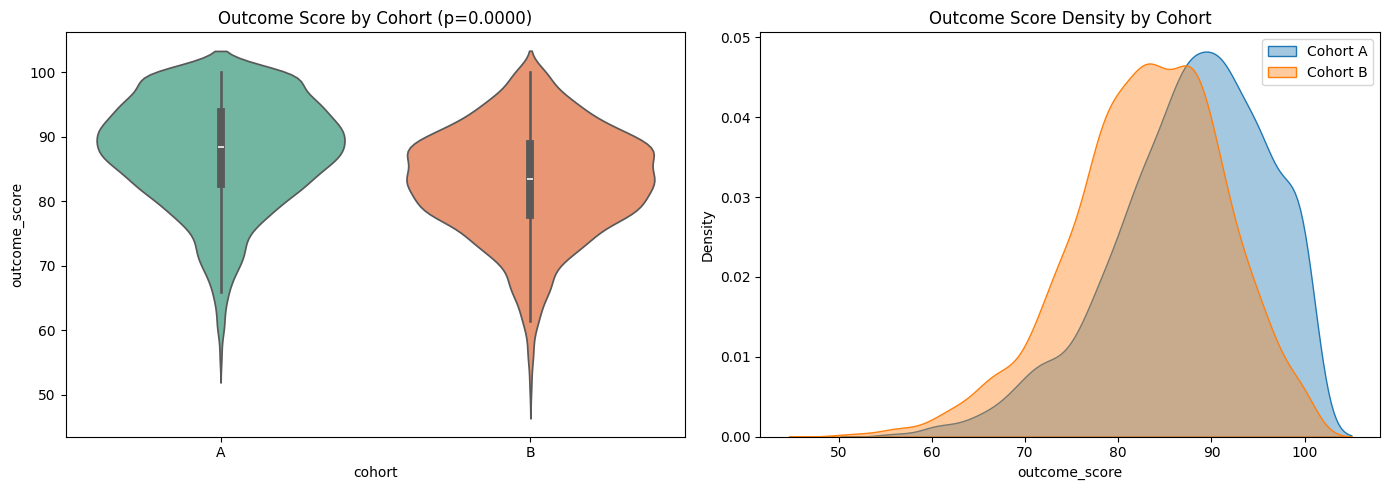

In [3]:
outcome_test = compare_cohorts_ttest(df, 'outcome_score')
for k, v in outcome_test.items():
    print(f'{k}: {v}')

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.violinplot(data=df, x='cohort', y='outcome_score', ax=axes[0], palette='Set2')
axes[0].set_title(f'Outcome Score by Cohort (p={outcome_test["p_value"]:.4f})')

sns.kdeplot(data=df[df['cohort']=='A'], x='outcome_score', ax=axes[1], label='Cohort A', fill=True, alpha=0.4)
sns.kdeplot(data=df[df['cohort']=='B'], x='outcome_score', ax=axes[1], label='Cohort B', fill=True, alpha=0.4)
axes[1].set_title('Outcome Score Density by Cohort')
axes[1].legend()
plt.tight_layout()
plt.show()

## 3. Compliance Comparison

In [4]:
comp_test = compare_cohorts_ttest(df, 'compliance_pct')
print('Compliance Comparison:')
for k, v in comp_test.items():
    print(f'  {k}: {v}')

Compliance Comparison:
  metric: compliance_pct
  cohort_a: A
  cohort_b: B
  mean_a: 87.909
  mean_b: 88.561
  std_a: 8.582
  std_b: 7.839
  n_a: 3120
  n_b: 2880
  t_statistic: -3.0749
  p_value: 0.002115
  cohens_d: -0.0792
  significant_at_05: True
  significant_at_01: True
  interpretation: There is a highly significant difference (p < 0.01) between cohorts A and B. The effect size is negligible (Cohen's d = -0.079). Cohort B shows higher mean scores.


## 4. Adverse Event Rate Comparison (Chi-Squared)

In [5]:
ae_test = compare_adverse_event_rates(df)
print('Adverse Event Rate Comparison:')
for k, v in ae_test.items():
    print(f'  {k}: {v}')

Adverse Event Rate Comparison:
  test: chi-squared
  cohort_a: A
  cohort_b: B
  rate_a: 0.1115
  rate_b: 0.1101
  chi2_statistic: 0.0196
  p_value: 0.888712
  degrees_of_freedom: 1
  significant_at_05: False


## 5. Temporal Trends by Cohort

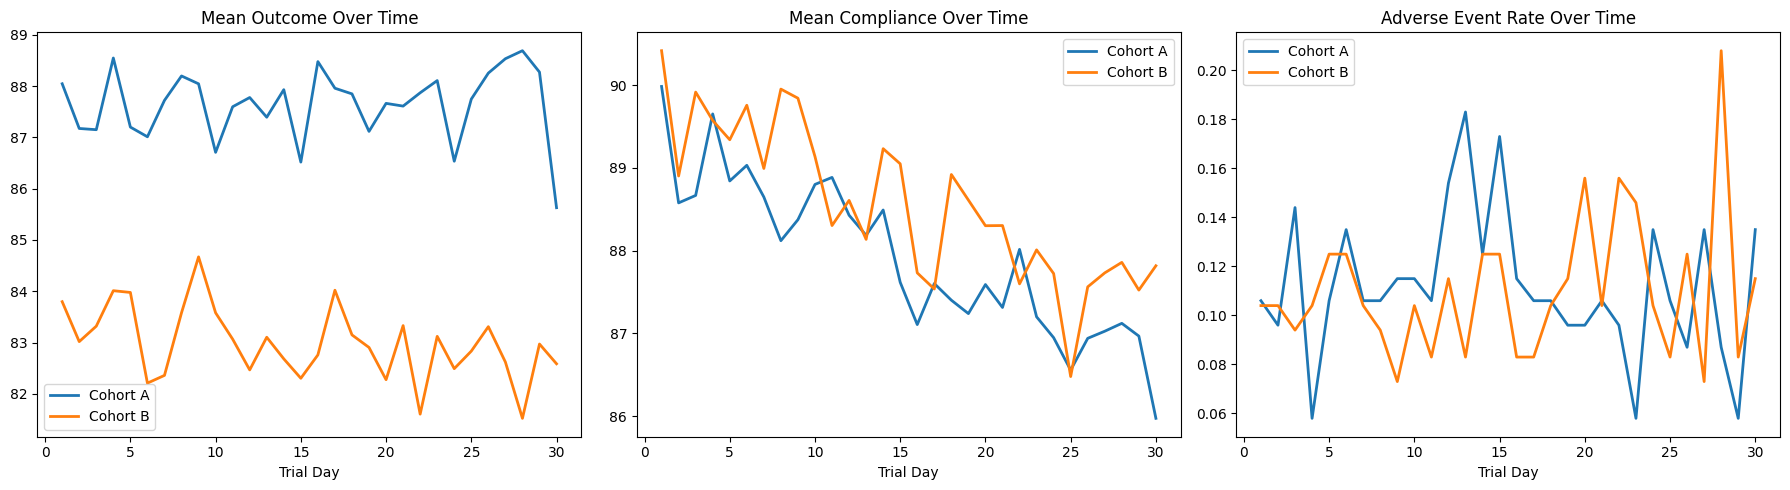

In [6]:
trends = compare_compliance_trends(df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for cohort in ['A', 'B']:
    ct = trends[trends['cohort'] == cohort]
    axes[0].plot(ct['trial_day'], ct['mean_outcome'], label=f'Cohort {cohort}', linewidth=2)
    axes[1].plot(ct['trial_day'], ct['mean_compliance'], label=f'Cohort {cohort}', linewidth=2)
    axes[2].plot(ct['trial_day'], ct['adverse_rate'], label=f'Cohort {cohort}', linewidth=2)

for i, title in enumerate(['Mean Outcome', 'Mean Compliance', 'Adverse Event Rate']):
    axes[i].set_title(f'{title} Over Time')
    axes[i].set_xlabel('Trial Day')
    axes[i].legend()

plt.tight_layout()
plt.show()

## 6. Dosage Distribution by Cohort

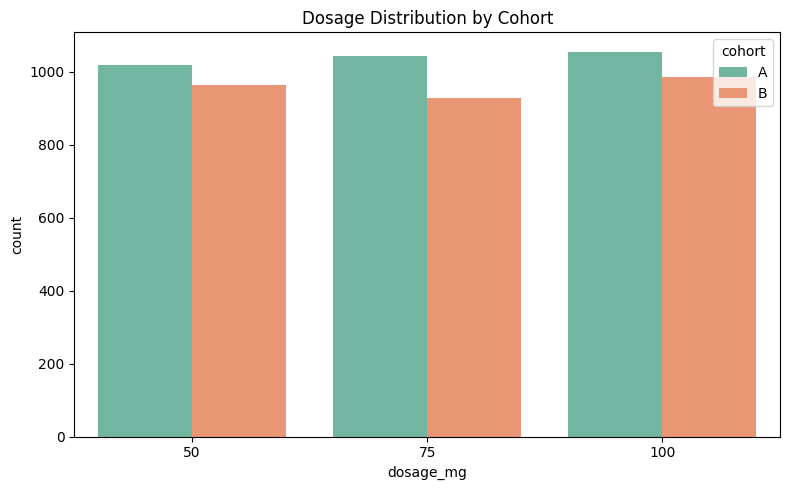

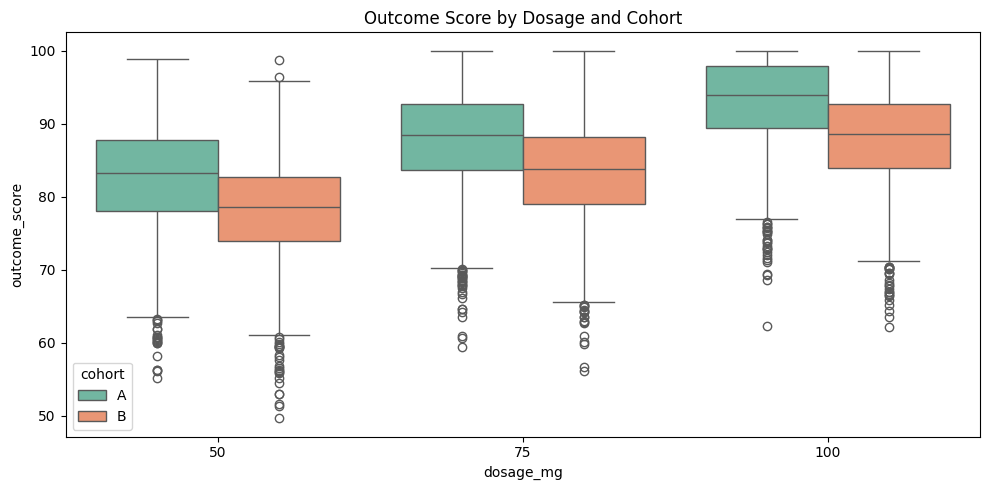

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='dosage_mg', hue='cohort', ax=ax, palette='Set2')
ax.set_title('Dosage Distribution by Cohort')
plt.tight_layout()
plt.show()

# Dosage vs outcome by cohort
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='dosage_mg', y='outcome_score', hue='cohort', ax=ax, palette='Set2')
ax.set_title('Outcome Score by Dosage and Cohort')
plt.tight_layout()
plt.show()

## 7. Full Analysis Summary

In [8]:
full = run_full_cohort_analysis(df)
print('\n=== COHORT ANALYSIS SUMMARY ===')
print(f'\nOutcome comparison:')
print(f'  Significant: {full["outcome_comparison"]["significant_at_05"]}')
print(f'  Effect size: {full["outcome_comparison"]["cohens_d"]}')
print(f'  Interpretation: {full["outcome_comparison"]["interpretation"]}')
print(f'\nAdverse event comparison:')
print(f'  Significant: {full["adverse_event_comparison"]["significant_at_05"]}')


=== COHORT ANALYSIS SUMMARY ===

Outcome comparison:
  Significant: True
  Effect size: 0.5601
  Interpretation: There is a highly significant difference (p < 0.01) between cohorts A and B. The effect size is medium (Cohen's d = 0.560). Cohort A shows higher mean scores.

Adverse event comparison:
  Significant: False


## Key Findings

- Cohort A shows moderately higher outcome scores than Cohort B
- Statistical significance confirmed via independent t-test
- Compliance patterns are similar between cohorts
- Adverse event rates do not significantly differ
- Temporal trends show consistent patterns across the trial period